In [114]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import ossify as osy

from standard_transform.datasets import v1dd_ds
import statsmodels.api as sm

from caveclient import CAVEclient

client = CAVEclient("v1dd")

## What is the relationship between the location of a synaptic output on an axon and its target cell type?

Here, we will put together skeleton structure and cell type information to look at the structure of how pyramidal cells distribute their output.

This analysis is inspired by an analysis from hippocampus in [Schmidt et al., Nature 2017](https://www.nature.com/articles/nature24005).
This paper found an offset between where an excitatory neuron synapsed onto inhibitory neurons (black lines) versus excitatory neurons (magenta lines):

![schmidt_figure_1f](img/axon_sorting.png){width=500px}

We are going to do a similar analysis for pyramidal cells in the V1dd dataset here.

In [ ]:
# To start with, let's build a list of all of the proofread cells and all clearly cell typed cells.

pf_df = client.materialize.tables.proofreading_status_and_strategy(
    status_axon=True
).query(split_positions=True)

ct_df = client.materialize.tables.cell_type_multifeature_v1().get_all(
    split_positions=True, desired_resolution=[1, 1, 1]
)
ct_df = ct_df.drop_duplicates(subset="pt_root_id", keep=False)


# Merge these two into one table and clean the table

pf_ct_df = pf_df.query("status_axon == True").merge(
    ct_df[["id", "pt_root_id", "classification_system", "cell_type"]].rename(
        columns={"id": "cell_id"}
    ),
    on="pt_root_id",
)[
    [
        "pt_root_id",
        "cell_id",
        "classification_system",
        "cell_type",
        "pt_position_x",
        "pt_position_y",
        "pt_position_z",
    ]
]

In [ ]:
root_id = pf_ct_df.query('cell_type == "L3IT"').pt_root_id.iloc[64]

cell = osy.load_cell_from_client(
    root_id=root_id,
    client=client,
    synapses=True,
    include_partner_root_id=True,
)

### Get an idea of what the cell looks like before doing analysis

<Axes: >

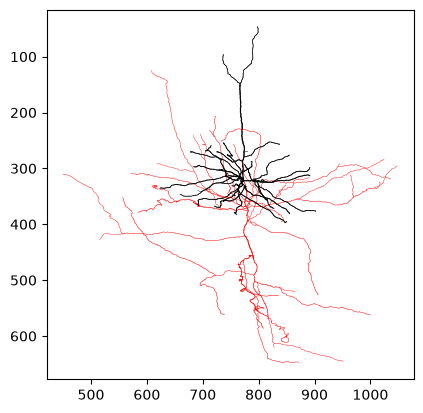

In [4]:
osy.plot.plot_morphology_2d(
    cell.transform(v1dd_ds.transform("nm").apply),
    color="compartment",
    palette={osy.SWC_DENDRITE: "black", osy.SWC_AXON: "red"},
    linewidth="radius",
    linewidth_norm=(100, 1000),
    widths=(0.25, 2),
)

In [5]:
# For clarity, let's make sure to only take output synapses on the axon of the cell. This avoids any false detections or small merges elsewhere on the cell.

cell_axon = cell.s.apply_mask(cell.s.df["compartment"] == osy.SWC_AXON)
pre_syn_anno = cell_axon.annotations.pre_syn
pre_syn_df = pre_syn_anno.df

In [6]:
pre_syn_df = pre_syn_df.merge(
    ct_df[["pt_root_id", "classification_system", "cell_type"]],
    how="left",
    left_on="post_pt_root_id",
    right_on="pt_root_id",
)

## Kinds of Distances

There are different ways of measuring the distance between two points in the EM datasets.
Let's consider the distance between a cell body and a synapse (red dot):

![Base neuron image](img/neuron_cartoon_base.png){height=500px}

### Euclidean

The direct line distance between the two points is the Euclidean distance.
It treats all axes the same, which may or may not work well in cortex.

![Euclidean distance](img/neuron_cartoon_euclidean.png){height=500px}

In [7]:
# Let's check the units

cell.s.root_location

# The high numbers indicate that the location in nm, as is default for skeletons

array([769792., 647417., 267165.])

In [8]:
euc_distance_um = (
    np.linalg.norm(
        pre_syn_anno.vertices - cell.s.root_location,
        axis=1,
    )
) / 1000.0  # Convert from nm to microns by dividing by 1000

pre_syn_df["dist_to_root_euc"] = euc_distance_um

<Axes: ylabel='Count'>

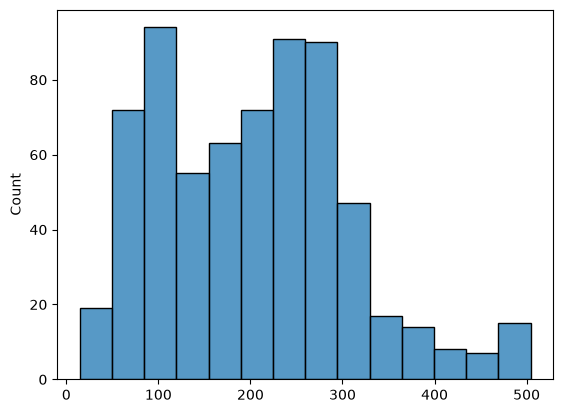

In [9]:
sns.histplot(euc_distance_um)

### Radial

Another way to measure locations is so-called cylindrical coordinates, where you distinguish a depth axis from a radial distance.
Here, we typically use the y-axis for cortical depth, so this radial distance is specifically within the x-z plane.
This approch treats radial distance as a different measure from distance along depth.

![Radial](img/neuron_cartoon_cylin.png){height=500px}

#### Streamline-radial distance (the better choice)

In practice, it turns out that cells do not follow a straight line from pia to white matter.
At a given location, apical dendrites and descending axons turn out to follow a "streamline" that is is specific to that location.
When measuring radial distances relative to a cell body at very different layers, it is useful to use the `radial_distance` function in `standard_transform`, which takes this streamline into account.

![streamline](img/steamline_correction_cartoon.png){height=500px}

Note: If you want to straighten a whole cell according to its streamline, you can do that via:
`cell_straightened = cell.transform(v1dd_ds.streamline('nm').transformer(cell.s.root_location))`

In [10]:
radial_distance_um = v1dd_ds.streamline("nm").radial_distance(
    cell.s.root_location,
    pre_syn_anno.vertices,
)

pre_syn_df["dist_to_root_radial"] = radial_distance_um

### Geodesic Distance

Geodesic distance refers to the shortest path along a surface or graph, and is the same as the **path length** plot in the Schmidt paper.
Here, we use it to refer to the distance along a neuronal skeleton.
Since the skeleton is a tree (i.e. there are no loops), the geodesic distance is the same as the one path between the cell body and the point in question (here, the synapse).

![Geodesic](img/neuron_cartoon_geod.png){height=500px}

In [11]:
# The skeleton is rooted at the cell body.We can simply use the distance_to_root function to get the geodesic distance
# along the skeleton from vertices in an annotation to the root vertex. There is also a pre_syn_anno.distance_between
# to compute a distance between vertices.

pre_syn_df["dist_to_root_geo"] = pre_syn_anno.distance_to_root() / 1000

**Questions:**

Before running the next cell, think about the relationship between these distances.

1. Which distance should be the shortest? The longest?
2. What limitation does geodesic distance have that Euclidean and radial distance does not have?

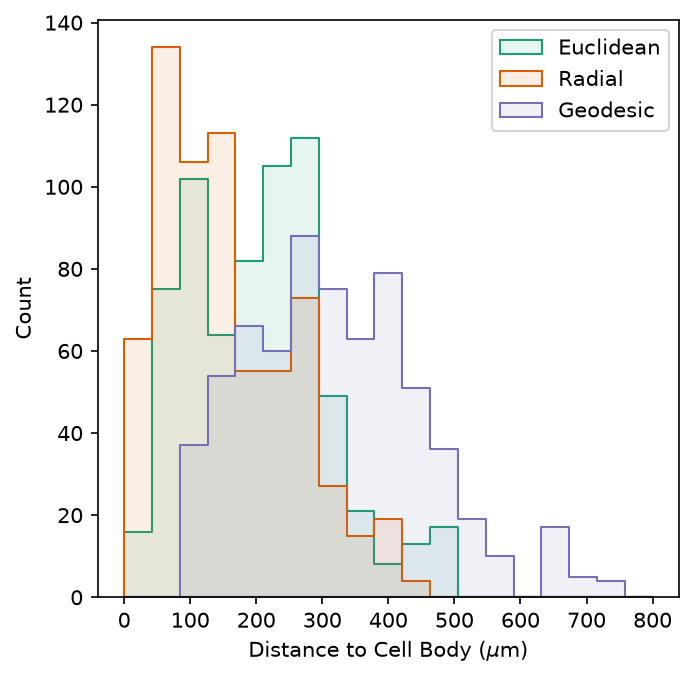

In [85]:
bins = np.linspace(0, 800, 20)

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

sns.histplot(
    pre_syn_df["dist_to_root_euc"],
    color=sns.color_palette("Dark2")[0],
    element="step",
    bins=bins,
    alpha=0.1,
)

sns.histplot(
    pre_syn_df["dist_to_root_radial"],
    color=sns.color_palette("Dark2")[1],
    element="step",
    bins=bins,
    alpha=0.1,
)

sns.histplot(
    pre_syn_df["dist_to_root_geo"],
    color=sns.color_palette("Dark2")[2],
    element="step",
    bins=bins,
    alpha=0.1,
)

ax.set_xlabel(r"Distance to Cell Body ($\mu$m)")
ax.legend(["Euclidean", "Radial", "Geodesic"])

**Question:**

Does the relative distributions of these curves make sense? 

#### How much axon is there?

The above just looked at synapses. If you want to know about the same distribution for axon itself, we can use similar functions on the skeleton to get this information:
1) `skeleton.distance_to_root` gives distance to root for each vertex (in nm by default)
2) `skeleton.half_edge_length` gives the amount of branch length associated with each skeleton vertex.

In [110]:
dist_axon_um = cell_axon.skeleton.distance_to_root() / 1_000
len_axon_um = cell_axon.skeleton.half_edge_length / 1_000

Text(0, 0.5, 'Microns of axon')

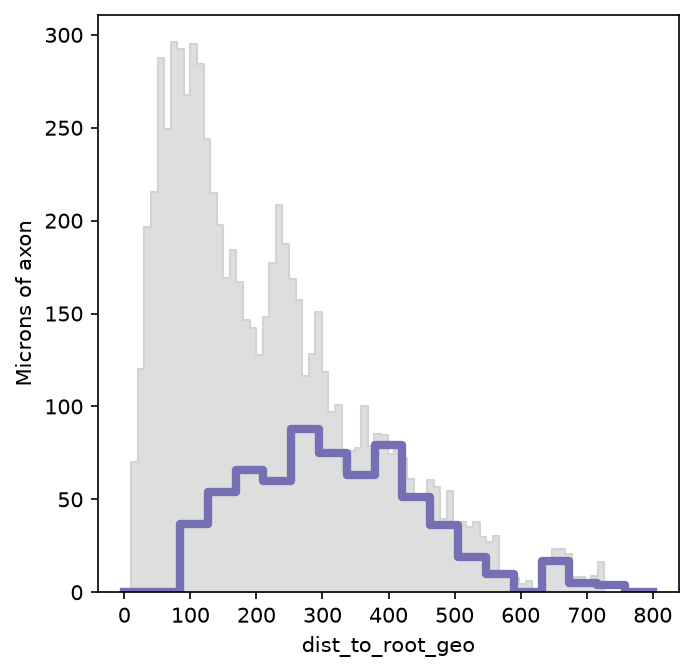

In [111]:
# For a quick plot, we can just treat this as a length-weighted histogram of skeleton vertex distances.

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)

sns.histplot(
    x=dist_axon_um,
    weights=len_axon_um,
    binwidth=10,
    color="lightgray",
    element="step",
    ax=ax,
)

sns.histplot(
    pre_syn_df["dist_to_root_geo"],
    color=sns.color_palette("Dark2")[2],
    element="step",
    bins=bins,
    alpha=1,
    fill=False,
    linewidth=4,
)

ax.set_ylabel("Microns of axon")

Similar approaches to synapses could be used to find radial and euclidean distances as well, using `cell.skeleton.vertices` to get the location of each skeleton vertex. 

## Cell Types and Distance

Now we come to our central question: how does target cell type vary with synapse distance?

In [13]:
# How many synapses actually have target classifications?

pre_syn_df.value_counts("classification_system")

classification_system
excitatory    144
inhibitory    123
Name: count, dtype: int64

In [14]:
# What is the distance between the median distance for excitatory and inhibitory targets?

pre_syn_df.groupby("classification_system").agg(
    med_dist_euc=pd.NamedAgg("dist_to_root_euc", "median"),
    med_dist_rad=pd.NamedAgg("dist_to_root_radial", "median"),
    med_dist_geo=pd.NamedAgg("dist_to_root_geo", "median"),
)

,med_dist_euc,med_dist_rad,med_dist_geo
classification_system,,,
excitatory,194.113942,120.621434,305.847096
inhibitory,130.908206,100.605603,239.901975


In [15]:
# Set some configuration variables for what's to come.

inh_color = "tomato"
exc_color = "navy"

distance_column = "dist_to_root_geo"

<Axes: xlabel='dist_to_root_geo', ylabel='Count'>

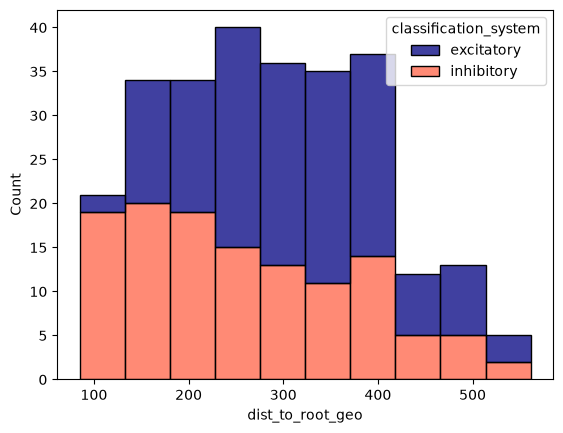

In [16]:
pre_syn_df_ct = pre_syn_df.dropna(subset="classification_system")

sns.histplot(
    x=distance_column,
    hue="classification_system",
    multiple="stack",
    data=pre_syn_df,
    palette={"excitatory": exc_color, "inhibitory": inh_color},
    hue_order=["excitatory", "inhibitory"],
)

### Approach 1: Binned inhibitory targeting fraction

Our first approach will be to split synapses into distance bins.
For each bin, we will treat the fraction of inhibitory targets as arising from a binomial process and estimate the probability.

In [17]:
# 10 bins along the first 300 microns of synapse-rich axon.

bins = np.linspace(
    pre_syn_df_ct[distance_column].min(),
    pre_syn_df_ct[distance_column].min() + 401,
    10,
)

In [18]:
ds = pre_syn_df_ct[distance_column]
is_inhib = pre_syn_df_ct["classification_system"] == "inhibitory"

k, _, _ = stats.binned_statistic(ds, is_inhib, "sum", bins=bins)
n, _, _ = stats.binned_statistic(ds, is_inhib, "count", bins=bins)

binom_res_inh = stats.binomtest(k=k, n=n)

# Handy for plots

bin_centers = bins[:-1] + np.diff(bins) / 2
binom_res_exc = stats.binomtest(k=n - k, n=n)

In [19]:
# Make a function that plots the estimated probability and confidence interval from a scipy binomial test


def plot_binom_filled(
    x,
    binom_res,
    color=None,
    linewidth=1,
    fill_alpha=0.25,
    method="wilson",
    ax=None,
    line_kwargs=None,
    fill_kwargs=None,
):
    """
    Parameters
    ----------
    x: np.ndarray
        X-axis locations associated with the binomial test
    binom_res:
        Results of scipy.stats.binomtest
    color: list or str
        Matplotlib-interpretable color
    linewidth:
        Width of the estimate line
    fill_alpha:
        Opacity of the confidence interval fill
    method:
        Method for confidence interal, by default "wilson"
    ax:
        matplotlib axis
    line_kwargs:
        Additional dictionary of keywords for the estimate plot (see ax.plot)
    fill_kwarg:
        Additional dictionary of keywords for the confidence interval plot (see ax.fill_between)
    """

    if ax is None:
        ax = plt.gca()
    if line_kwargs is None:
        line_kwargs = {}
    if fill_kwargs is None:
        fill_kwargs = {}

    ax.fill_between(
        x,
        binom_res.proportion_ci(method=method).low,
        binom_res.proportion_ci(method=method).high,
        color=color,
        alpha=fill_alpha,
        **fill_kwargs,
    )
    ax.plot(
        x,
        binom_res.proportion_estimate,
        color=color,
        linewidth=linewidth,
        **line_kwargs,
    )
    return ax

<Axes: >

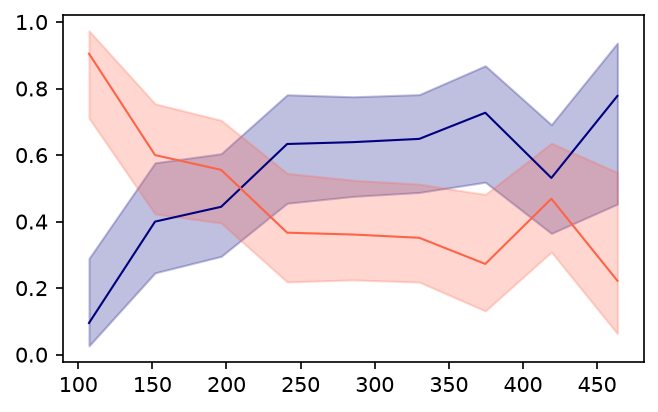

In [20]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=150)

plot_binom_filled(
    bin_centers,
    binom_res_exc,
    ax=ax,
    color=exc_color,
)

plot_binom_filled(
    bin_centers,
    binom_res_inh,
    ax=ax,
    color=inh_color,
)

**Questions:**

1) What are the weaknesses and assumptions of this approach?
2) Look at other cells. How typical is this range?
3) What do you notice about the typical pattern of where synapses are and where the crossover between inhibitory and excitatory targets is?
4) If you have time, use the cell type field (not just "classification") to explore if any specific inhibitory subclass drives this effect?

### Approach 2: Fit all the data together

It looks like the probability of a synapse being inhibitory is monotonic, with a value generally decreasing and stabilizing to some steady value with distance.
We can model this by fitting all the points to a sigmoidal curve using statsmodels.
Unlike the binned data, it accounts for both the exact distances and the amount of data available along the range of distances.

If we assume that the probability of a synapse being inhibitory at a given distance follows a sigmoidal function, there are two parameters to fit, which we write down as $\beta_0$ and $\beta_1$.
$$p(s_{inhib} \mid d) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 d)}}$$
The first value, $\beta_0$ sets the probability at $d=0$ while $\beta_1$ says how fast the probability changes with distance, and in which direction. Negative values mean the probability decreases with distance, positive values indicate it increases with distance.

It is actually simpler to think about on the log-odds scale:

$$\log \frac{p(s_{inhib} \mid d)}{1 - p(s_{inhib} \mid d)} = \beta_0 + \beta_1 d$$

A standard approach to fitting data is figure out what parameters $\beta_0$ and $\beta_1$ maximum the probability of the data points.
This is *maximum likelihood estimatation*.
In practice, we typically minimize the negative of the log of the probability, simply because that is an easier number to work with and has the same answer.

In [ ]:
from scipy.optimize import minimize


def sigmoid_prob_is_inhib(beta, ds):
    return 1 / (1 + np.exp(-(beta[0] + beta[1] * ds)))


def sigmoid_log_loss(beta, ds, value):
    z = beta[0] + beta[1] * ds
    return np.sum(
        np.logaddexp(0, z) - value * z
    )  # np.logaddexp(0,z) is just np.log(exp^0 + exp^z)


fit = minimize(sigmoid_log_loss, [0, 0], args=(ds, is_inhib))

b0, b1 = fit.x

Text(0.5, 0, 'dist_to_root_geo')

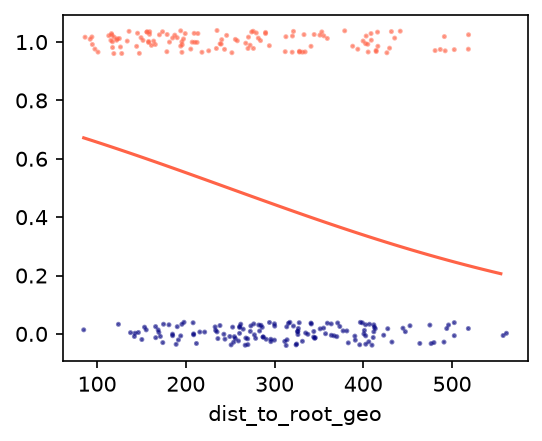

In [ ]:
x_grid = np.arange(
    pre_syn_df_ct[distance_column].min(), pre_syn_df_ct[distance_column].max(), 10
)

fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
ax.plot(x_grid, sigmoid_prob_is_inhib(fit.x, x_grid), color=inh_color)

rng = np.random.default_rng(0)
jit = rng.uniform(-0.04, 0.04, len(is_inhib))
ax.scatter(
    ds,
    is_inhib.to_numpy().astype(bool) + jit,
    s=2,
    alpha=0.5,
    c=np.where(is_inhib, inh_color, exc_color),
)
ax.set_xlabel(distance_column)

The math works, but there are better tools out there for this sort of statistical modeling.
In particular, `statsmodels` is a python package that not only computes best fits, but also confidence intervals and a number of other statistical features.

We can do the same operation with statsmodels and get a p-value on the coefficient of the distance function.
In the summary below, look at `P>|z|` for the value of `dist_to_root_geo`.
It is negative and, for the default cell, should have a vanishingly low p-value, indicating that this change in inhibitory connection probability with distance is significant.

In [69]:
import statsmodels.api as sm

X = sm.add_constant(ds)
res = sm.GLM(is_inhib.to_numpy().astype(int), X, family=sm.families.Binomial()).fit()
print(res.summary())

print(f"Odds Ratio per 100 µm: {np.exp(res.params[1] * 100)}")


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  267
Model:                            GLM   Df Residuals:                      265
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -176.93
Date:                Mon, 03 Aug 2026   Deviance:                       353.87
Time:                        12:15:51   Pearson chi2:                     268.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.05329
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.0891      0.356  

/var/folders/wq/w_ly72m51xq4y98tg0ddrpqc0000gn/T/ipykernel_22553/3462918267.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Odds Ratio per 100 µm: {np.exp(res.params[1] * 100)}")


Text(0.5, 0, 'dist_to_root_geo')

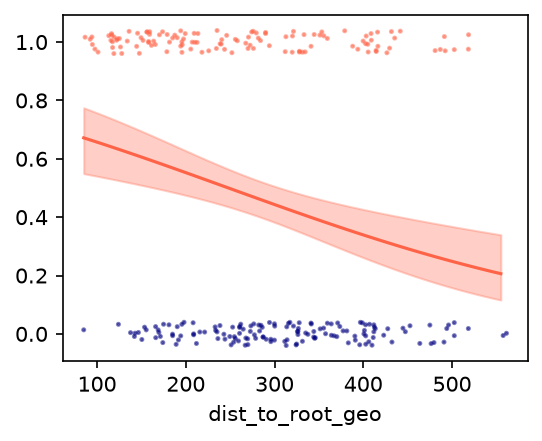

In [ ]:
# We can now plot the same thing, but with the confidence intervals that statsmodels gave us.

grid_X = sm.add_constant(x_grid)
pred = res.get_prediction(grid_X).summary_frame()

fig, ax = plt.subplots(figsize=(4, 3), dpi=150)

ax.plot(x_grid, pred["mean"], color=inh_color)
ax.fill_between(
    x_grid, pred["mean_ci_lower"], pred["mean_ci_upper"], alpha=0.3, color=inh_color
)

ax.scatter(
    ds,
    is_inhib.to_numpy().astype(bool) + jit,
    s=2,
    alpha=0.5,
    c=np.where(is_inhib, inh_color, exc_color),
)
ax.set_xlabel(distance_column)

**Questions**

1. Does this hold with other cells?
2. Consider both the trends and the absolute numbers. What assumptions are required for this analysis to be correct? Do you think these hold in practice?
3. What about inhibitory cells?
4. How do all of these functions behave if we chose different distance functions? What do you think that means biologically?
5. Can you think of any other ways to split up the connections for these cells?
6. This sigmoidal fit was just one model of how connections form and are distributed across an arbor. What aspects of the data does it capture, and which does it not? Can you think of different models that might approach this data differently?